In [1]:
import pandas as pd

# 1. Load the dataset
url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt"

columns = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes'] + \
          [f'feature_{i}' for i in range(6, 41)] + ['class', 'difficulty']

df = pd.read_csv(url, names=columns)

# 2. Inspect the dataset shape
print("Dataset Shape:", df.shape)

# 3. Display the first 5 rows
df.head()

Dataset Shape: (125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,feature_6,feature_7,feature_8,feature_9,...,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,class,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


Total Missing Values: 0


C:\Users\jook\AppData\Local\Temp\ipykernel_5348\2911216353.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class', palette='Set2')


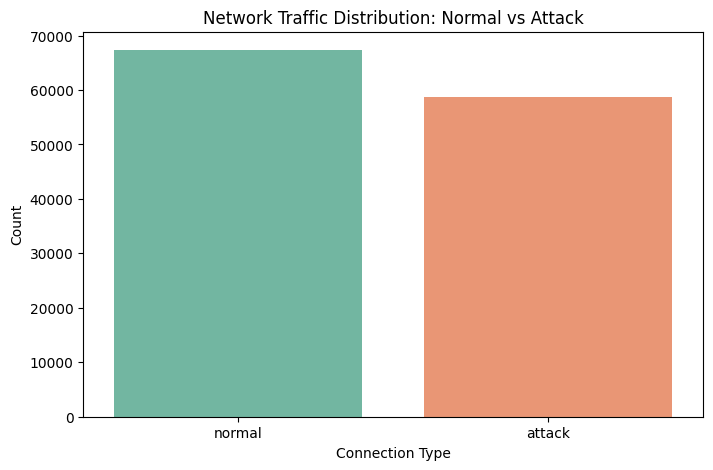

In [2]:
# 4. Check for missing values in the entire dataset
missing_values = df.isnull().sum().max()
print(f"Total Missing Values: {missing_values}")

# 5. Visualizing the Target Class (Normal vs Attack)
import matplotlib.pyplot as plt
import seaborn as sns

# Simplify classes: group everything that is not 'normal' into 'attack'
df['class'] = df['class'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

# Plot the distribution using a bar chart
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='class', palette='Set2')
plt.title('Network Traffic Distribution: Normal vs Attack')
plt.xlabel('Connection Type')
plt.ylabel('Count')
plt.show()

In [4]:
# 6. Data Encoding (Converting Text to Numbers)
from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataframe to avoid changing the original yet
df_encoded = df.copy()

# Initialize the LabelEncoder
encoder = LabelEncoder()

# List of columns that contain text (Categorical columns)
text_columns = ['protocol_type', 'service', 'flag', 'class']

# Apply the encoder to each text column
for col in text_columns:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

# Print the first 5 rows to see the transformation
print("Data after Encoding:")
print(df_encoded[['protocol_type', 'service', 'flag', 'class']].head())

Data after Encoding:
   protocol_type  service  flag  class
0              1       20     9      1
1              2       44     9      1
2              1       49     5      0
3              1       24     9      1
4              1       24     9      1
